<a href="https://colab.research.google.com/github/tigersingh020-ship-it/create-REspository/blob/mainline/Copy_of_EDA_DataCleaning_Bengaluru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA + Data Cleaning Notebook — Bengaluru House Prices

**Today’s goal:** Learn Exploratory Data Analysis (EDA) and core data cleaning techniques using a real dataset.

✅ We will practice:
- Previewing data (`head`, `sample`)
- Understanding structure (`shape`, `info`, `describe`)
- Missing values & duplicates
- String cleaning (locations)
- Converting text → numeric (`size` → `bhk`, `total_sqft`)
- Feature engineering (`price_per_sqft`)
- Visualizations (histogram, boxplot, scatter)
- Simple outlier removal

> **Dataset file used here:** `Bengaluru_House_Data.csv`


## 1) Setup + Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 2) Quick Preview (EDA)
**Talking points:**
- `head()` shows the first few rows
- `sample()` shows random rows (helps spot messy patterns)


In [ ]:
df.sample(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
7164,Super built-up Area,Ready To Move,Padmanabhanagar,2 BHK,Gancy P,1067,2.0,2.0,52.00
6074,Super built-up Area,Ready To Move,Haralur Road,2 BHK,RInceeg,1243,2.0,2.0,46.00
8702,Super built-up Area,Ready To Move,Konena Agrahara,2 BHK,EsadeNS,1075,2.0,1.0,57.00
9065,Super built-up Area,Ready To Move,Kaggadasapura,2 BHK,Gincyi,960,2.0,1.0,45.00
11252,Super built-up Area,20-Oct,Banashankari Stage VI,3 BHK,Brens7,1392,3.0,1.0,69.46


## 3) Dataset Structure
**Talking points:**
- `shape` = (rows, columns)
- `columns` = feature names
- `info()` shows data types + missing counts


In [ ]:
print("Shape:", df.shape)
df.columns

Shape: (13320, 9)


Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


## 4) Summary Statistics (Numeric Columns)
**Talking points:**
- `describe()` helps catch weird min/max values
- Outliers often show up as extremely large max values


In [ ]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


## 5) Missing Values
**Talking points:**
- Missing values are normal in real datasets
- We must decide: drop or fill


In [ ]:
df.isnull().sum().sort_values(ascending=False)

## 6) Drop Columns We Don’t Need (For This Project)
We’ll keep only:
- `location`, `size`, `total_sqft`, `bath`, `price`

This keeps today focused on cleaning + EDA.


In [ ]:
df2 = df.drop(['area_type','availability','society','balcony'], axis=1)
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [ ]:
df2.isnull().sum().sort_values(ascending=False)

,0
bath,73
size,16
location,1
total_sqft,0
price,0


## 7) Handle Missing Values (Simple Approach)
For today, we drop rows missing key values.


In [ ]:
df3 = df2.dropna().copy()
df3.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [ ]:
print('Shape after dropna:', df3.shape)

Shape after dropna: (13246, 5)


## 8) Duplicate Rows
Duplicates can skew results and visuals.


In [ ]:
df3.duplicated().sum()

np.int64(881)

In [ ]:
df3 = df3.drop_duplicates().copy()
print("Shape after dropping duplicates:", df3.shape)

Shape after dropping duplicates: (12365, 5)


## 9) Categorical Exploration: Location
**Talking points:**
- Categories with many spellings/spaces cause issues
- Visualization and ML treat them as different categories unless we clean


In [ ]:
df3['location'].value_counts().head(10)

,count
location,
Whitefield,501
Sarjapur Road,357
Electronic City,273
Thanisandra,223
Kanakpura Road,217
Yelahanka,206
Marathahalli,164
Raja Rajeshwari Nagar,153
Bannerghatta Road,149


## 10) String Cleaning: `location`
We standardize locations by:
- removing extra spaces: `.str.strip()`
- consistent casing: `.str.title()`


In [ ]:
df3['location'] = df3['location'].str.strip().str.title()
df3['location'].value_counts().head(10)

,count
location,
Whitefield,502
Sarjapur Road,357
Electronic City,275
Thanisandra,225
Kanakpura Road,217
Yelahanka,206
Marathahalli,164
Raja Rajeshwari Nagar,153
Bannerghatta Road,149


## 11) Convert Text → Numeric: `size` → `bhk`
Examples:
- "2 BHK" → 2
- "4 Bedroom" → 4

ML models need numbers, not text.


In [ ]:
df3['bhk'] = df3['size'].apply(lambda x: int(str(x).split()[0]))
df3[['size','bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


## 12) Clean `total_sqft`
This column can contain:
- plain numbers ("1200")
- ranges ("1133 - 1384")
- other formats

We convert ranges to their average.


In [ ]:
def convert_sqft(x):
    x = str(x)
    parts = x.split('-')
    if len(parts) == 2:
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return None
    try:
        return float(x)
    except:
        return None

df3['total_sqft'] = df3['total_sqft'].apply(convert_sqft)
df3 = df3[df3['total_sqft'].notnull()].copy()
df3[['total_sqft']].head()

,total_sqft
0,1056.0
1,2600.0
2,1440.0
3,1521.0
4,1200.0


In [ ]:
print('Shape after cleaning total_sqft:', df3.shape)

Shape after cleaning total_sqft: (12319, 6)


## 13) Feature Engineering: `price_per_sqft`
This helps detect unrealistic listings (outliers).


In [ ]:
df3['price_per_sqft'] = (df3['price']*100000) / df3['total_sqft']
df3[['price','total_sqft','price_per_sqft']].head()

,price,total_sqft,price_per_sqft
0,39.07,1056.0,3699.810606
1,120.00,2600.0,4615.384615
2,62.00,1440.0,4305.555556
3,95.00,1521.0,6245.890861
4,51.00,1200.0,4250.000000


## 14) Visualization: Histogram (Price Distribution)
Histograms show how values are spread.


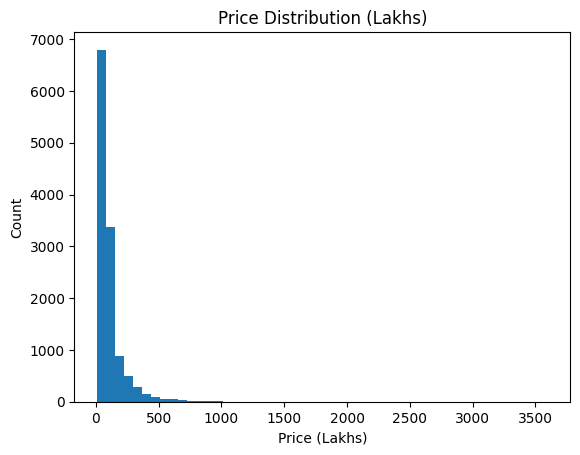

In [ ]:
plt.figure()
plt.hist(df3['price'], bins=50)
plt.title("Price Distribution (Lakhs)")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")
plt.show()

## 15) Visualization: Boxplot (Outliers in price_per_sqft)
Boxplots highlight extreme values.


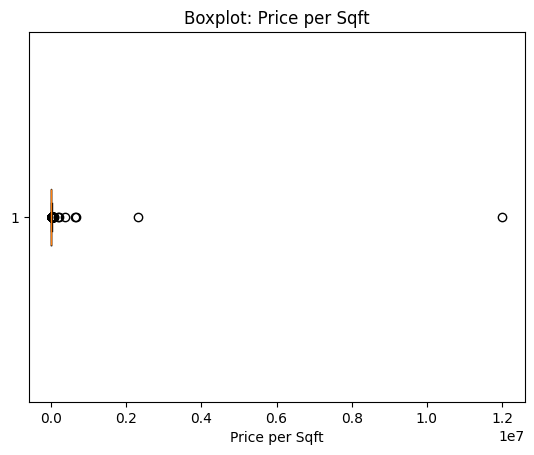

In [ ]:
plt.figure()
plt.boxplot(df3['price_per_sqft'].dropna(), vert=False)
plt.title("Boxplot: Price per Sqft")
plt.xlabel("Price per Sqft")
plt.show()

## 16) Visualization: Scatter Plot (Sqft vs Price)
Shows relationship between size and price.


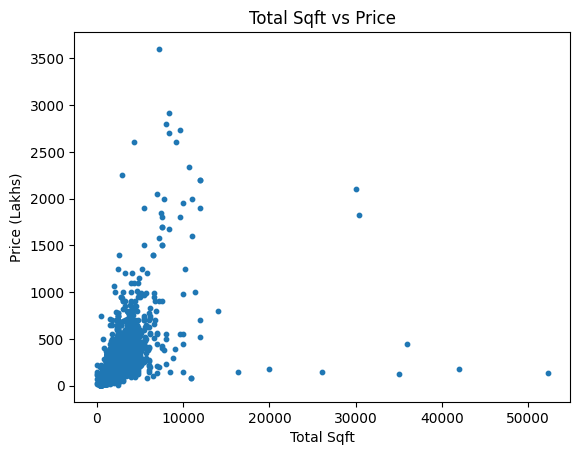

In [ ]:
plt.figure()
plt.scatter(df3['total_sqft'], df3['price'], s=10)
plt.title("Total Sqft vs Price")
plt.xlabel("Total Sqft")
plt.ylabel("Price (Lakhs)")
plt.show()

## 17) Simple Outlier Removal (Teaching Version)
We remove extremely low/high `price_per_sqft` values.
(Keep it simple for learning.)


In [ ]:
before = df3.shape[0]
df3 = df3[(df3['price_per_sqft'] > 1000) & (df3['price_per_sqft'] < 40000)].copy()
after = df3.shape[0]
print("Rows before:", before)
print("Rows after :", after)

Rows before: 12319
Rows after : 12289


# Exercises (Do These)
### Exercise 1 — Missing Values
- Which column had the most missing values in the raw dataset (`df`)?
- How many rows remain after `dropna()` in `df3`?

### Exercise 2 — Location Cleaning
- Print 10 random locations **before** cleaning and **after** cleaning.
(Hint: keep a copy of the original column first)

### Exercise 3 — BHK Values
- How many unique BHK values exist?
- What are the top 5 most common BHK values?

### Exercise 4 — Outliers
- What are the min and max of `price_per_sqft` before filtering?
- What are they after filtering?

### Exercise 5 — Visualization
- Make a histogram for `total_sqft`.


In [ ]:
# Starter code for Exercise 5
plt.figure()
plt.hist(df3['total_sqft'], bins=50)
plt.title("Total Sqft Distribution")
plt.xlabel("Total Sqft")
plt.ylabel("Count")
plt.show()